# Imagined left versus right movement

Our target is **75% overall accuracy** for subjects 1-10. Each person has
45 trials, so the evaluation contains **450 predictions**.

The final model is intentionally simple: average EEG voltage over short time
blocks, scale the resulting numbers, and train logistic regression. Read
`motor_imagery_simple.py` for the complete commented code. No actual-movement
recordings are used.


In [1]:
import os
from pathlib import Path

# Keep library configuration inside this project.
os.environ['_MNE_FAKE_HOME_DIR'] = str(Path.cwd())
os.environ['MPLCONFIGDIR'] = str(Path.cwd() / '.mplconfig')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from motor_imagery_simple import load_subject, make_model, run_evaluation


## 1. Turn each EEG trial into a row of numbers

Use runs **4, 8 and 12**, which contain imagined left/right fist movement.
For each trial:

1. Take EEG samples from 0.5 to 4.0 seconds after its cue.
2. Subtract the average electrode voltage at each time point.
3. Split the 3.5 seconds into seven half-second blocks.
4. Average each electrode's voltage within each block.

There are 64 electrodes, so each trial becomes **64 x 7 = 448 features**.
No neighboring trial, trial position, previous label or future trial is used.
There is no continuous temporal filter that could mix nearby trials.


In [2]:
features, labels, runs = load_subject(1)
print('Feature table:', features.shape)
print('Left trials:', np.sum(labels == 0))
print('Right trials:', np.sum(labels == 1))
print('Recording runs:', np.unique(runs))


Feature table: (45, 448)
Left trials: 23
Right trials: 22
Recording runs: [ 4  8 12]


## 2. Use a small, regularized classifier

`StandardScaler` learns the average and spread of each feature using training
trials only. `LogisticRegression` then learns a weighted combination of those
features to predict left (0) or right (1). Its small `C=0.01` limits overfitting
because each fold has only 30 training trials.


In [3]:
model = make_model()
print(model)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.01, max_iter=1000))])


## 3. Test on complete recording runs

For each person, train on two runs and test on the third:

| Training runs | Test run |
| --- | --- |
| 8, 12 | 4 |
| 4, 12 | 8 |
| 4, 8 | 12 |

Every trial is tested exactly once. A new scaler and classifier are fitted for
each fold. These are within-person predictions for another run, not predictions
for a completely new person. The 75% target refers to the overall score, not
to every person's individual score.


In [4]:
subject_results, summary = run_evaluation()
print()
print(subject_results.to_string(float_format=lambda value: f'{value:.4f}'))


Subject  1: 82.22%


Subject  2: 80.00%


Subject  3: 86.67%


Subject  4: 82.22%


Subject  5: 57.78%


...

Subject  7: 84.44%


Subject  8: 77.78%


Subject  9: 93.33%


Subject 10: 62.22%



Overall: 345/450 correct = 76.67%
75% overall target met: True
Confusion matrix (rows=true, columns=predicted; left then right):
[[185  45]
 [ 60 160]]

         correct  trials  accuracy
subject                           
1             37      45    0.8222
2             36      45    0.8000
3             39      45    0.8667
4             37      45    0.8222
5             26      45    0.5778
6             27      45    0.6000
7             38      45    0.8444
8             35      45    0.7778
9             42      45    0.9333
10            28      45    0.6222


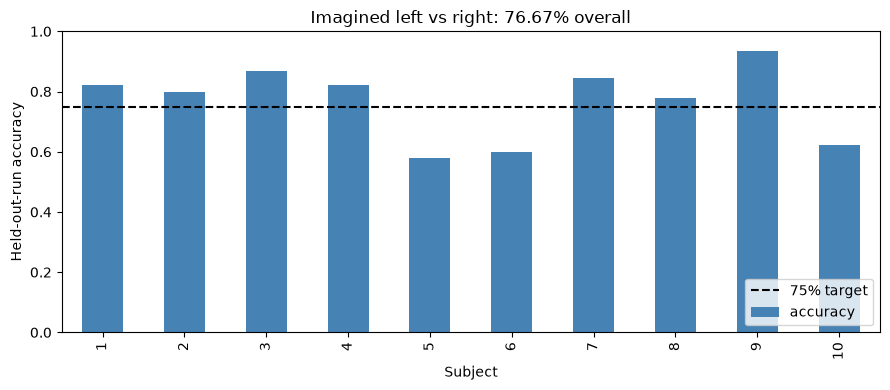

In [5]:
ax = subject_results['accuracy'].plot.bar(figsize=(9, 4), color='steelblue')
ax.axhline(0.75, color='black', linestyle='--', label='75% target')
ax.set_ylim(0, 1)
ax.set_xlabel('Subject')
ax.set_ylabel('Held-out-run accuracy')
ax.set_title(f"Imagined left vs right: {summary['accuracy']:.2%} overall")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/imagery_simple/accuracy_by_subject.png', dpi=150)
plt.show()


## 4. Check the saved predictions

`predictions.csv` contains all 450 true labels, predictions and model
probabilities. The following checks reconstruct the result directly.


In [6]:
predictions = pd.read_csv('results/imagery_simple/predictions.csv')
assert len(predictions) == 450
assert not predictions.duplicated(['subject', 'trial']).any()
assert predictions.groupby('subject').size().eq(45).all()
measured_accuracy = (predictions['truth'] == predictions['prediction']).mean()
assert np.isclose(measured_accuracy, summary['accuracy'])
print(f"Verified: {summary['correct']}/450 = {measured_accuracy:.2%}")


Verified: 345/450 = 76.67%


## What the result does and does not show

The measured development cross-validation score is **76.67%**, compared with
58.22% for the original short-window CSP model and 63.56% for the first revised
pipeline on the same run-separated evaluation. A more complex combined model
scored 77.33%; the single logistic-regression model was retained for readability.

We compared multiple methods on these recordings. The final model was chosen
after that investigation, so this is **not an untouched final test set**.
Independent new recordings are needed to confirm 75% generalization.

The experiment displays a left/right visual target. EEG can contain visual
responses and eye-related activity as well as motor-related signals. Therefore,
this is classification of **cued imagery recordings**, not proof of reading
motor intention alone. In matching controls, using motor-region electrodes
alone scored 70.22%, and entirely before-cue samples scored 56.44%. The latter
also shows some predictability exists before the imagery period.

Two hundred label-shuffle controls averaged 50.30% (maximum 57.78%). These
controls hold the final feature design fixed; they do not adjust for every
exploratory model comparison. A subject-level bootstrap gives a rough 95%
interval of 69.11%-83.56%, illustrating uncertainty from only ten people.

Dataset protocol: [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/).
See `RESULTS.md` for the investigation and saved controls.
